In [156]:
import pandas as pd
import numpy as np 

1.1 LOAD THE TOXICITY DATASET 

In [157]:
df = pd.read_csv('data.csv')

1.2 EDA - Dataset Inspection

In [158]:
head = df.head()
shape = df.shape  
columns = df.columns  
info = df.info() 
missing_total = df.isnull().sum().sum()
target_counts = df['Class'].value_counts()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171 entries, 0 to 170
Columns: 1204 entries, MATS3v to Class
dtypes: float64(1003), int64(200), object(1)
memory usage: 1.6+ MB


In [159]:

# Print all info after EDA
print("===== Head of Dataset =====")
print(head)
print("\n===== Dataset Shape =====")
print(shape)
print("\n===== Columns =====")
print(columns)
print("\n===== Total Missing Values =====")
print(missing_total)
print("\n===== Target Distribution =====")
print(target_counts)

===== Head of Dataset =====
   MATS3v  nHBint10  MATS3s  MATS3p  nHBDon_Lipinski  minHBint8  MATS3e  \
0  0.0908         0  0.0075  0.0173                0        0.0 -0.0436   
1  0.0213         0  0.1144 -0.0410                0        0.0  0.1231   
2  0.0018         0 -0.0156 -0.0765                2        0.0 -0.1138   
3 -0.0251         0 -0.0064 -0.0894                3        0.0 -0.0747   
4  0.0135         0  0.0424 -0.0353                0        0.0 -0.0638   

   MATS3c  minHBint2  MATS3m  ...   WTPT-4   WTPT-5  ETA_EtaP_L  ETA_EtaP_F  \
0  0.0409        0.0  0.1368  ...   0.0000   0.0000      0.1780      1.5488   
1 -0.0316        0.0  0.1318  ...   8.8660  19.3525      0.1739      1.3718   
2 -0.1791        0.0  0.0615  ...   5.2267  27.8796      0.1688      1.4395   
3 -0.1151        0.0  0.0361  ...   7.7896  24.7336      0.1702      1.4654   
4  0.0307        0.0  0.0306  ...  12.3240  19.7486      0.1789      1.4495   

   ETA_EtaP_B  nT5Ring  SHdNH  ETA_dEpsilon_C 

1.3 EDA - Visualizations

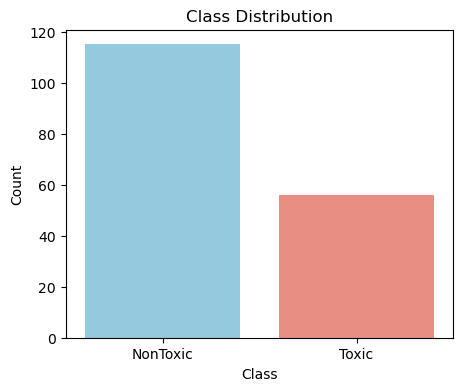

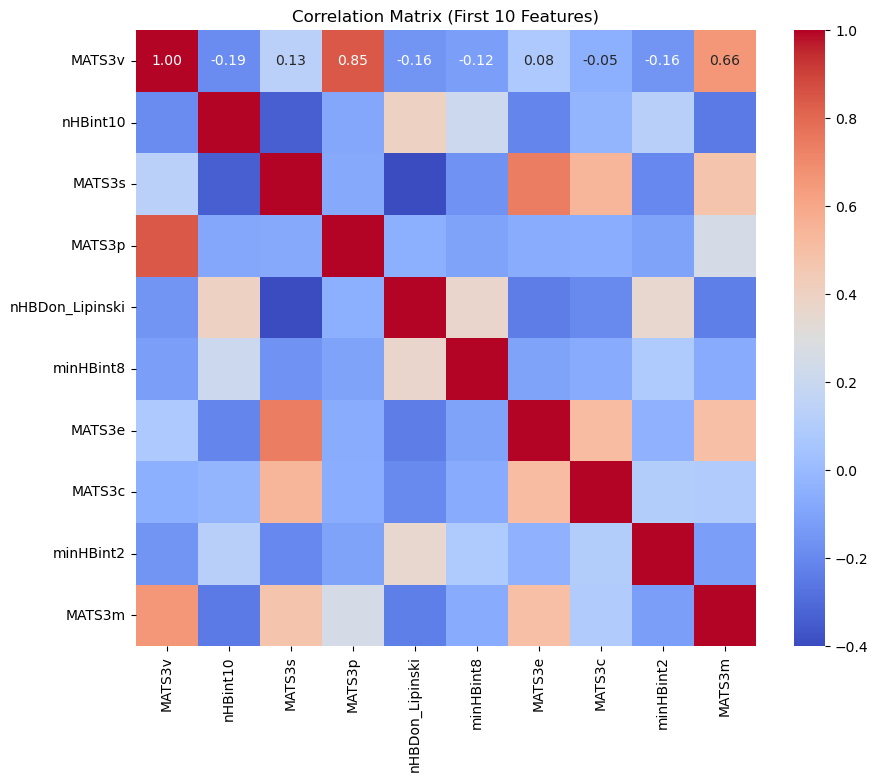

In [160]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Visualize target distribution
plt.figure(figsize=(5,4))
sns.countplot(x='Class', data=df, palette=['skyblue','salmon'])
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# 2️⃣ Correlation matrix (first 10 features for clarity)
corr_matrix = df.drop(columns='Class').iloc[:, :10].corr()  # select first 10 features
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix (First 10 Features)")
plt.show()



2. DATA PREPROCESSING 

In [161]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [162]:
# preprocessing reusable func.
# returns: X (features), y (encoded target), preprocessors dict
def preprocess_data(df, target_col='Class'):
    
    df_clean = df.copy()
    
    # Handle infinite values
    df_clean = df_clean.replace([np.inf, -np.inf], np.nan)
    
    # Separate numeric and categorical columns
    numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
    
    # Remove target from categorical list if present
    if target_col in categorical_cols:
        categorical_cols.remove(target_col)
    
    # Initialize imputers as None (will only be created if needed)
    imputer_num = None
    imputer_cat = None
    
    # Impute numeric columns with median
    if numeric_cols:
        imputer_num = SimpleImputer(strategy='median')
        df_clean[numeric_cols] = imputer_num.fit_transform(df_clean[numeric_cols])
    
    # Impute categorical columns with most frequent
    if categorical_cols:
        imputer_cat = SimpleImputer(strategy='most_frequent')
        df_clean[categorical_cols] = imputer_cat.fit_transform(df_clean[categorical_cols])
    
    # Remove duplicate rows
    df_clean = df_clean.drop_duplicates().reset_index(drop=True)
    
    # Encode categorical features
    encoders = {}
    for col in categorical_cols:
        le = LabelEncoder()
        df_clean[col] = le.fit_transform(df_clean[col].astype(str))
        encoders[col] = le
    
    # Encode target
    le_target = LabelEncoder()
    df_clean[target_col] = le_target.fit_transform(df_clean[target_col])
    encoders[target_col] = le_target
    
    # Remove constant numeric features
    constant_cols = [col for col in numeric_cols if df_clean[col].std() == 0]
    if constant_cols:
        df_clean.drop(columns=constant_cols, inplace=True)
        numeric_cols = [c for c in numeric_cols if c not in constant_cols]
    
    # Scale numeric features
    scaler = StandardScaler()
    df_clean[numeric_cols] = scaler.fit_transform(df_clean[numeric_cols])
    
    # Separate features and target
    X = df_clean.drop(target_col, axis=1)
    y = df_clean[target_col]
    
    preprocessors = {
        'numeric_imputer': imputer_num,
        'categorical_imputer': imputer_cat,
        'encoders': encoders,
        'scaler': scaler,
        'numeric_cols': numeric_cols,
        'categorical_cols': categorical_cols
    }
    
    return X, y, preprocessors

# Now use the function
X, y, preprocessors = preprocess_data(df, target_col='Class')

print("Features shape:", X.shape)
print("Target distribution:", pd.Series(y).value_counts())

Features shape: (171, 1203)
Target distribution: Class
0    115
1     56
Name: count, dtype: int64



------
3. FEATURE SELECTION

-----


Top 10 features (F-score):
['EE_Dt', 'C2SP2', 'AATSC7p', 'SpDiam_Dt', 'MLogP', 'MATS7p', 'nAcid', 'nwHBa', 'GATS7v', 'SpMin4_Bhi']

Top 10 features (Random Forest Importance):
['SpAD_Dt', 'EE_Dt', 'MATS3v', 'ATSC7c', 'MDEC-23', 'ATSC7p', 'ZMIC1', 'MATS6c', 'AATSC5s', 'GATS4c']

✅ Selected features (appear in at least one method): ['SpAD_Dt', 'SpMin4_Bhi', 'MLogP', 'AATSC5s', 'ZMIC1', 'ATSC7p', 'C2SP2', 'MDEC-23', 'GATS4c', 'nAcid', 'nwHBa', 'MATS3v', 'MATS7p', 'GATS7v', 'AATSC7p', 'ATSC7c', 'MATS6c', 'EE_Dt', 'SpDiam_Dt']
Final feature set shape: (171, 19)


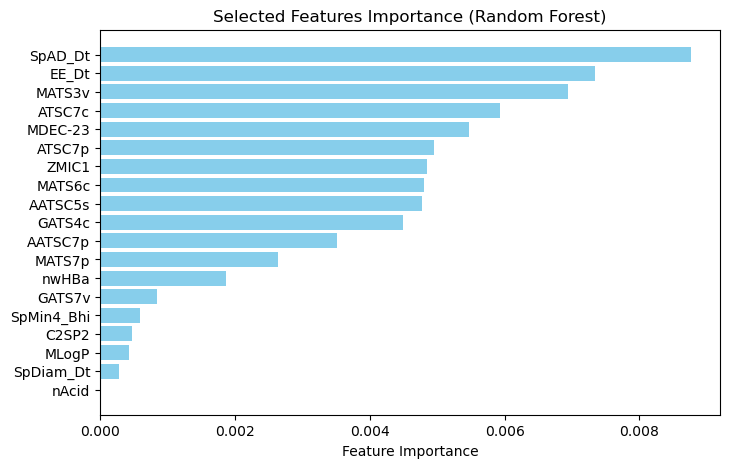

In [163]:

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier


# --- Method 1: SelectKBest (F-score) ---
selector_f = SelectKBest(score_func=f_classif, k=min(10, X.shape[1]))
selector_f.fit(X, y)
feature_scores_f = pd.DataFrame({
    'Feature': X.columns,
    'F-Score': selector_f.scores_
}).sort_values('F-Score', ascending=False)

top_features_f = feature_scores_f.head(10)['Feature'].tolist()
print("\nTop 10 features (F-score):")
print(top_features_f)

# --- Method 2: Random Forest Feature Importance ---
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)
feature_scores_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

top_features_rf = feature_scores_rf.head(10)['Feature'].tolist()
print("\nTop 10 features (Random Forest Importance):")
print(top_features_rf)

# --- Features selected by at least one method ---
selected_features = list(set(top_features_f) | set(top_features_rf))
print(f"\n✅ Selected features (appear in at least one method): {selected_features}")

# --- Final dataset ---
X_selected = X[selected_features]
print(f"Final feature set shape: {X_selected.shape}")

# --- Feature importance visualization (Random Forest) ---
plt.figure(figsize=(8,5))
plt.barh(feature_scores_rf[feature_scores_rf['Feature'].isin(selected_features)]['Feature'],
         feature_scores_rf[feature_scores_rf['Feature'].isin(selected_features)]['Importance'],
         color='skyblue')
plt.xlabel("Feature Importance")
plt.title("Selected Features Importance (Random Forest)")
plt.gca().invert_yaxis()
plt.show()

4.MODEL EVALUATION WITH CROSS-VALIDATION 
---------
Cross-validation evaluates models more reliably than a single train-test split by using all data for training and testing across multiple folds.

In [164]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, VotingClassifier

# Use final dataset (feature-selected if available)
X_final = X_selected if 'X_selected' in globals() else X
y_final = y

print(f"Dataset shape: {X_final.shape}")
print(f"Class distribution:\n{y_final.value_counts()}")

# Stratified K-Fold setup
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Base models
rf = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
ab = AdaBoostClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

# Voting ensemble (soft voting for probabilities)
voting = VotingClassifier(
    estimators=[('RF', rf), ('GB', gb), ('AB', ab)],
    voting='soft',
    n_jobs=-1
)

# All models to evaluate
models = {
    'Random Forest': rf,
    'Gradient Boosting': gb,
    'AdaBoost': ab,
    'Voting Ensemble': voting
}

# Metrics
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

print("="*70)
print("CROSS-VALIDATION RESULTS (5-Fold Stratified)")
print("="*70)

cv_results = {}
for name, model in models.items():
    cv_score = cross_validate(model, X_final, y_final, cv=skf, scoring=scoring, n_jobs=-1)
    cv_results[name] = cv_score
    
    print(f"\n{name}:")
    print(f"  Accuracy:  {cv_score['test_accuracy'].mean():.4f} ± {cv_score['test_accuracy'].std():.4f}")
    print(f"  Precision: {cv_score['test_precision'].mean():.4f} ± {cv_score['test_precision'].std():.4f}")
    print(f"  Recall:    {cv_score['test_recall'].mean():.4f} ± {cv_score['test_recall'].std():.4f}")
    print(f"  F1 Score:  {cv_score['test_f1'].mean():.4f} ± {cv_score['test_f1'].std():.4f}")
    print(f"  ROC-AUC:   {cv_score['test_roc_auc'].mean():.4f} ± {cv_score['test_roc_auc'].std():.4f}")

Dataset shape: (171, 19)
Class distribution:
Class
0    115
1     56
Name: count, dtype: int64
CROSS-VALIDATION RESULTS (5-Fold Stratified)

Random Forest:
  Accuracy:  0.6373 ± 0.0310
  Precision: 0.4024 ± 0.0977
  Recall:    0.2167 ± 0.1109
  F1 Score:  0.2661 ± 0.1118
  ROC-AUC:   0.6570 ± 0.0414

Gradient Boosting:
  Accuracy:  0.6491 ± 0.0374
  Precision: 0.4550 ± 0.0602
  Recall:    0.3439 ± 0.1785
  F1 Score:  0.3646 ± 0.1409
  ROC-AUC:   0.5923 ± 0.0707

AdaBoost:
  Accuracy:  0.6491 ± 0.0494
  Precision: 0.4544 ± 0.1281
  Recall:    0.2864 ± 0.0698
  F1 Score:  0.3484 ± 0.0834
  ROC-AUC:   0.6082 ± 0.0526

Voting Ensemble:
  Accuracy:  0.6430 ± 0.0486
  Precision: 0.5467 ± 0.2353
  Recall:    0.3258 ± 0.1501
  F1 Score:  0.3515 ± 0.1174
  ROC-AUC:   0.6360 ± 0.0334


 -------------------------------
 PICK THE BEST MODEL FROM CV
 -------------------------------

In [ ]:


# Choose metric to compare models
metric = 'roc_auc'  # could also use 'f1', 'accuracy', etc.

best_model_name = None
best_score = 0

for name, scores in cv_results.items():
    mean_score = scores[f'test_{metric}'].mean()
    print(f"{name}: Mean {metric.upper()} = {mean_score:.4f}")
    
    if mean_score > best_score:
        best_score = mean_score
        best_model_name = name

print("\n" + "="*50)
print(f"✅ Best model based on {metric.upper()}: {best_model_name} ({best_score:.4f})")
print("="*50)

Random Forest: Mean ROC_AUC = 0.6570
Gradient Boosting: Mean ROC_AUC = 0.5923
AdaBoost: Mean ROC_AUC = 0.6082
Voting Ensemble: Mean ROC_AUC = 0.6360

✅ Best model based on ROC_AUC: Random Forest (0.6570)


In [166]:
# -------------------------------
# TRAIN THE BEST MODEL ON FULL DATASET
# -------------------------------

from sklearn.ensemble import RandomForestClassifier

# Initialize the best model with chosen hyperparameters
best_model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)

# Train on the entire dataset
best_model.fit(X_final, y_final)

print("✓ Best model (Random Forest) trained on full dataset")

✓ Best model (Random Forest) trained on full dataset


-----
FEATURE IMPORTANCE
------

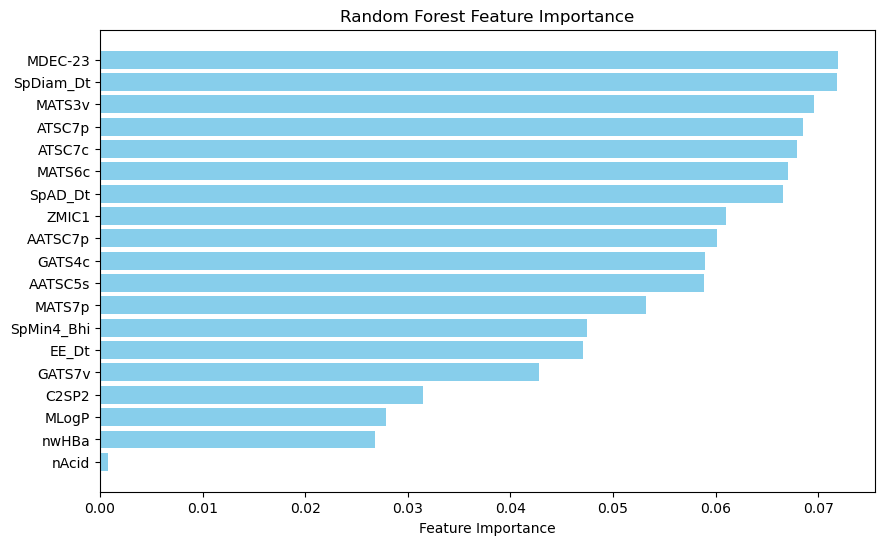

In [167]:
# Get feature importances
importances = best_model.feature_importances_
feature_names = X_final.columns

feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Quick visualization
plt.figure(figsize=(10,6))
plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'], color='skyblue')
plt.gca().invert_yaxis()
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance')
plt.show()